# Modellazione base

In [2]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, classification_report
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV
import pickle

In [3]:
sentinels = ['None', 'n.d.', ' ', '']
df = pd.read_csv('assets/nid_out.tsv', sep='\t', na_values=sentinels)
# print("df.shape: ", df.shape)


df.mediaVoto.fillna(df.mediaVoto.mean(), inplace=True)
df = df.drop(['luogoDiNascita', 'nazioneNascita'], axis=1)
# print(pd.isnull(df).sum() > 0)

In [4]:
df.columns

Index(['ID_Stud', 'annoAccaCors', 'annoCorso', 'annoDiNascita', 'cittadinanza',
       'codCorso', 'creditiTotali', 'facolta', 'flagIdentificato', 'iscritto',
       'primaIscr', 'sesso', 'tipoCorso', 'tipoIscrizione', 'tipoStudente',
       'ultIscr', 'cfuPrenotati', 'ultPren', 'cfuTake', 'ultSup', 'mediaVoto',
       'lastLogin', 'Dropout'],
      dtype='object')

In [7]:
y = df.Dropout
X = df.drop(['ID_Stud', 'Dropout', 'lastLogin', 'annoAccaCors', 'ultIscr'], axis = 1) #  'ultSup', 'ultPren', 'annoCorso', 'annoDiNascita', 'primaIscr'
# print(X.head())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Training Set shape: {}".format(X_train.shape))
print("Test Set shape: {}".format(X_test.shape))

Training Set shape: (58580, 18)
Test Set shape: (14646, 18)


In [8]:
ohe_elements =  ['cittadinanza', 'facolta', 'tipoIscrizione']
encoder = OneHotEncoder(handle_unknown="ignore")
feature_arr = encoder.fit_transform(X_train[ohe_elements]).toarray()
feature_labels = encoder.get_feature_names_out()
feature_labels = np.array(feature_labels).ravel()
encoded_df = pd.DataFrame(feature_arr, columns=feature_labels)
X_train = X_train.reset_index(drop=True)
X_train = X_train.join(encoded_df)
X_train = X_train.drop(ohe_elements, axis=1)
with open('assets/encoder.pickle', 'wb') as f:
    pickle.dump(encoder, f)
X_train.head()

,annoCorso,annoDiNascita,codCorso,creditiTotali,flagIdentificato,iscritto,primaIscr,sesso,tipoCorso,tipoStudente,...,facolta_MEDICINA E PSICOLOGIA,facolta_PSICOLOGIA 1,"facolta_SCIENZE MATEMATICHE, FISICHE E NATURALI","facolta_SCIENZE POLITICHE, SOCIOLOGIA, COMUNICAZIONE",facolta_SCIENZE STATISTICHE,facolta_SCUOLA DI INGEGNERIA AEROSPAZIALE,tipoIscrizione_FUORI CORSO,tipoIscrizione_IMMATRICOLAZIONE,tipoIscrizione_IN CORSO,tipoIscrizione_RIPETENTE
0,3,883609200,29902,300,0,False,1514761200,True,23,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3,820450800,29949,180,1,True,1546297200,True,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,694220400,29942,120,1,True,1514761200,True,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2,599612400,29402,180,0,True,1577833200,True,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,1009839600,30850,180,0,True,1609455600,False,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
ohe_elements =  ['cittadinanza', 'facolta', 'tipoIscrizione']
with open('assets/encoder.pickle', 'rb') as f:
    encoder = pickle.load(f)


feature_arr = encoder.transform(X_test[ohe_elements]).toarray()
feature_labels = encoder.get_feature_names_out()
feature_labels = np.array(feature_labels).ravel()
encoded_df = pd.DataFrame(feature_arr, columns=feature_labels)
X_test = X_test.reset_index(drop=True)
X_test = X_test.join(encoded_df)
X_test = X_test.drop(ohe_elements, axis=1)

X_test.head()

,annoCorso,annoDiNascita,codCorso,creditiTotali,flagIdentificato,iscritto,primaIscr,sesso,tipoCorso,tipoStudente,...,facolta_MEDICINA E PSICOLOGIA,facolta_PSICOLOGIA 1,"facolta_SCIENZE MATEMATICHE, FISICHE E NATURALI","facolta_SCIENZE POLITICHE, SOCIOLOGIA, COMUNICAZIONE",facolta_SCIENZE STATISTICHE,facolta_SCUOLA DI INGEGNERIA AEROSPAZIALE,tipoIscrizione_FUORI CORSO,tipoIscrizione_IMMATRICOLAZIONE,tipoIscrizione_IN CORSO,tipoIscrizione_RIPETENTE
0,4,694220400,28230,120,1,False,1420066800,True,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,788914800,30061,120,0,True,1577833200,False,28,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,946681200,30789,360,1,True,1546297200,False,29,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,883609200,31279,120,1,True,1609455600,False,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,883609200,30425,180,1,False,1546297200,False,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Decision Tree

Confusion matrix:
 [[10393   570]
 [  622  3061]]
Balanced Accuracy Score:  0.8895614352514787
Score:  0.9186125904683873
Classification report:
               precision    recall  f1-score   support

       False       0.94      0.95      0.95     10963
        True       0.84      0.83      0.84      3683

    accuracy                           0.92     14646
   macro avg       0.89      0.89      0.89     14646
weighted avg       0.92      0.92      0.92     14646



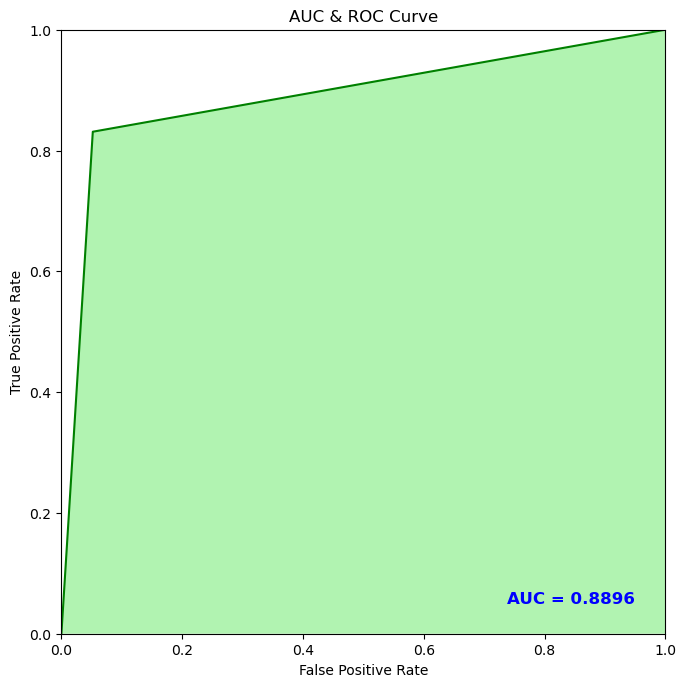

In [10]:
classifier = tree.DecisionTreeClassifier()#, min_impurity_decrease=0.1) Senza max depth ci mette 0.9, così 0.1
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
# plt.figure(figsize=(24,14))
# tree.plot_tree(classifier, filled=True, fontsize=14)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

bas = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy Score: ", bas)

s = classifier.score(X_test, y_test)
print("Score: ", s)

print("Classification report:\n", classification_report(y_test, y_pred)) # Plottare errore epoca per epoca su train e test oppure stampare direttamente i due valori di AUROC
auc = metrics.roc_auc_score(y_test, y_pred)

false_positive_rate, true_positive_rate, thresolds = metrics.roc_curve(y_test, y_pred)

plt.figure(figsize=(10, 8), dpi=100)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")
plt.plot(false_positive_rate, true_positive_rate, 'g')
plt.fill_between(false_positive_rate, true_positive_rate, facecolor='lightgreen', alpha=0.7)
plt.text(0.95, 0.05, 'AUC = %0.4f' % auc, ha='right', fontsize=12, weight='bold', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [11]:
print(classifier.get_params())
print(classifier.get_depth())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': None, 'splitter': 'best'}
40


In [12]:
c_names = X_train.columns
imp = dict(zip(c_names, classifier.feature_importances_))
print(sorted(imp.items(), key=lambda x: x[1], reverse=True))

[('ultSup', 0.31917826190870463), ('primaIscr', 0.2068108243644087), ('ultPren', 0.13563167549460722), ('cfuTake', 0.05692982293565137), ('codCorso', 0.042512665739827996), ('annoDiNascita', 0.030599264175360862), ('iscritto', 0.03016361086709373), ('annoCorso', 0.028702303569457258), ('tipoIscrizione_IMMATRICOLAZIONE', 0.02587623768222824), ('mediaVoto', 0.021425484395914147), ('creditiTotali', 0.01757433267832344), ('tipoIscrizione_IN CORSO', 0.016055013483104133), ('sesso', 0.00873316827857057), ('tipoCorso', 0.007210876214048296), ('flagIdentificato', 0.0065547336368025075), ('cfuPrenotati', 0.0041940063037023325), ('tipoStudente', 0.0037875898883632476), ('facolta_INGEGNERIA CIVILE E INDUSTRIALE', 0.0031456150491688943), ('facolta_LETTERE E FILOSOFIA', 0.0030781456901036054), ('facolta_SCIENZE POLITICHE, SOCIOLOGIA, COMUNICAZIONE', 0.002998289331275253), ('facolta_ECONOMIA', 0.0027594183903209), ('facolta_ARCHITETTURA', 0.0025326118260442505), ('facolta_Interfacolta tra FARMACIA E

## Random Forest

Confusion matrix:
 [[10396   567]
 [  540  3143]]
Balanced Accuracy Score:  0.9008304882745701
Score:  0.9244162228594838
Classification report:
               precision    recall  f1-score   support

       False       0.95      0.95      0.95     10963
        True       0.85      0.85      0.85      3683

    accuracy                           0.92     14646
   macro avg       0.90      0.90      0.90     14646
weighted avg       0.92      0.92      0.92     14646



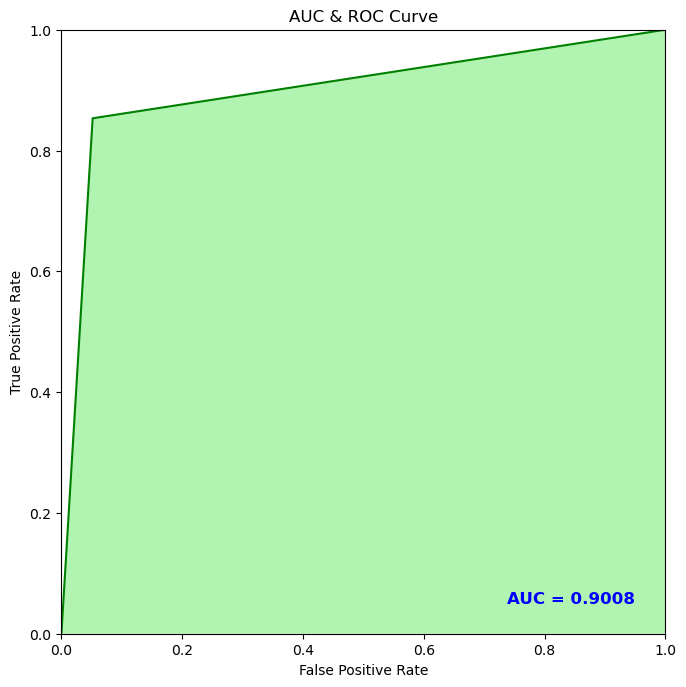

In [13]:
classifier = RandomForestClassifier()
classifier = classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

# print(classifier.get_params())

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

bas = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy Score: ", bas)

s = classifier.score(X_test, y_test)
print("Score: ", s)

print("Classification report:\n", classification_report(y_test, y_pred))

auc = metrics.roc_auc_score(y_test, y_pred)

false_positive_rate, true_positive_rate, thresolds = metrics.roc_curve(y_test, y_pred)

plt.figure(figsize=(10, 8), dpi=100)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")
plt.plot(false_positive_rate, true_positive_rate, 'g')
plt.fill_between(false_positive_rate, true_positive_rate, facecolor='lightgreen', alpha=0.7)
plt.text(0.95, 0.05, 'AUC = %0.4f' % auc, ha='right', fontsize=12, weight='bold', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [14]:
classifier.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [15]:
c_names = X_train.columns
imp = dict(zip(c_names, classifier.feature_importances_))
print(sorted(imp.items(), key=lambda x: x[1], reverse=True))

[('ultSup', 0.2519278019732654), ('ultPren', 0.14488680312398156), ('primaIscr', 0.1345921021543688), ('cfuTake', 0.07087814609907782), ('codCorso', 0.06137369589676609), ('annoDiNascita', 0.055436439948365446), ('mediaVoto', 0.03927299691861882), ('annoCorso', 0.03840569293201655), ('iscritto', 0.03591698831853453), ('cfuPrenotati', 0.027466101486639347), ('tipoIscrizione_IMMATRICOLAZIONE', 0.01718818190564472), ('tipoIscrizione_IN CORSO', 0.012309276502029967), ('sesso', 0.011032955833593077), ('tipoCorso', 0.010619621015062084), ('creditiTotali', 0.010208216601945895), ('flagIdentificato', 0.010157378514025749), ('tipoIscrizione_FUORI CORSO', 0.009137396635622578), ('facolta_LETTERE E FILOSOFIA', 0.004830452544612404), ('tipoStudente', 0.00411418954965732), ('cittadinanza_ITA', 0.004036800259842449), ('facolta_Interfacolta tra FARMACIA E MEDICINA - MEDICINA E ODONTOIATRIA', 0.0037958302468664457), ('facolta_SCIENZE POLITICHE, SOCIOLOGIA, COMUNICAZIONE', 0.003729740148707818), ('faco

In [16]:
classifier.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## Support Vector Machine

In [17]:
X_train.head()

,annoCorso,annoDiNascita,codCorso,creditiTotali,flagIdentificato,iscritto,primaIscr,sesso,tipoCorso,tipoStudente,...,facolta_MEDICINA E PSICOLOGIA,facolta_PSICOLOGIA 1,"facolta_SCIENZE MATEMATICHE, FISICHE E NATURALI","facolta_SCIENZE POLITICHE, SOCIOLOGIA, COMUNICAZIONE",facolta_SCIENZE STATISTICHE,facolta_SCUOLA DI INGEGNERIA AEROSPAZIALE,tipoIscrizione_FUORI CORSO,tipoIscrizione_IMMATRICOLAZIONE,tipoIscrizione_IN CORSO,tipoIscrizione_RIPETENTE
0,3,883609200,29902,300,0,False,1514761200,True,23,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3,820450800,29949,180,1,True,1546297200,True,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,694220400,29942,120,1,True,1514761200,True,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2,599612400,29402,180,0,True,1577833200,True,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,1009839600,30850,180,0,True,1609455600,False,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [18]:
from imblearn.over_sampling import SMOTE
X_smote = X_train.copy()
smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X_smote, y_train)

In [19]:
scaler = StandardScaler()
std_elements = ['ultPren', 'annoCorso', 'annoDiNascita', 'primaIscr', 'creditiTotali',  'cfuPrenotati',
       'cfuTake', 'mediaVoto']#, 'lastLogin'] 'annoAccaCors', 'ultSup', 'ultPren', 'annoCorso', 'annoDiNascita' 'primaIscr', 'ultIscr',
X_train_std = X_train.copy()
X_train_std[std_elements] = scaler.fit_transform(X_train_std[std_elements])
with open('assets/scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)  
X_train_std.head()

,annoCorso,annoDiNascita,codCorso,creditiTotali,flagIdentificato,iscritto,primaIscr,sesso,tipoCorso,tipoStudente,...,facolta_MEDICINA E PSICOLOGIA,facolta_PSICOLOGIA 1,"facolta_SCIENZE MATEMATICHE, FISICHE E NATURALI","facolta_SCIENZE POLITICHE, SOCIOLOGIA, COMUNICAZIONE",facolta_SCIENZE STATISTICHE,facolta_SCUOLA DI INGEGNERIA AEROSPAZIALE,tipoIscrizione_FUORI CORSO,tipoIscrizione_IMMATRICOLAZIONE,tipoIscrizione_IN CORSO,tipoIscrizione_RIPETENTE
0,0.674940,0.190506,29902,2.097027,0,False,-0.167545,True,23,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.674940,-0.296241,29949,0.044378,1,True,0.232004,True,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.826237,-1.269071,29942,-0.981946,1,True,-0.167545,True,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.075648,-1.998193,29402,0.044378,0,True,0.631553,True,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.826237,1.163335,30850,0.044378,0,True,1.032197,False,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [20]:
with open('assets/scaler.pickle', 'rb') as f:
    scaler = pickle.load(f)

X_test_std = X_test.copy()
X_test_std[std_elements] = scaler.fit_transform(X_test_std[std_elements])

In [21]:
X_test_std.head()

,annoCorso,annoDiNascita,codCorso,creditiTotali,flagIdentificato,iscritto,primaIscr,sesso,tipoCorso,tipoStudente,...,facolta_MEDICINA E PSICOLOGIA,facolta_PSICOLOGIA 1,"facolta_SCIENZE MATEMATICHE, FISICHE E NATURALI","facolta_SCIENZE POLITICHE, SOCIOLOGIA, COMUNICAZIONE",facolta_SCIENZE STATISTICHE,facolta_SCUOLA DI INGEGNERIA AEROSPAZIALE,tipoIscrizione_FUORI CORSO,tipoIscrizione_IMMATRICOLAZIONE,tipoIscrizione_IN CORSO,tipoIscrizione_RIPETENTE
0,1.421446,-1.260355,28230,-0.978449,1,False,-1.371699,True,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.074243,-0.531040,30061,-0.978449,0,True,0.641321,False,28,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.074243,0.684042,30789,3.102243,1,True,0.238938,False,29,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.822088,0.198276,31279,-0.978449,1,True,1.044808,False,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.074243,0.198276,30425,0.041724,1,False,0.238938,False,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Confusion matrix:
 [[7683 3280]
 [ 649 3034]]
Balanced Accuracy Score:  0.7622983897482136
Score:  0.7317356274750785
Classification report:
               precision    recall  f1-score   support

       False       0.92      0.70      0.80     10963
        True       0.48      0.82      0.61      3683

    accuracy                           0.73     14646
   macro avg       0.70      0.76      0.70     14646
weighted avg       0.81      0.73      0.75     14646



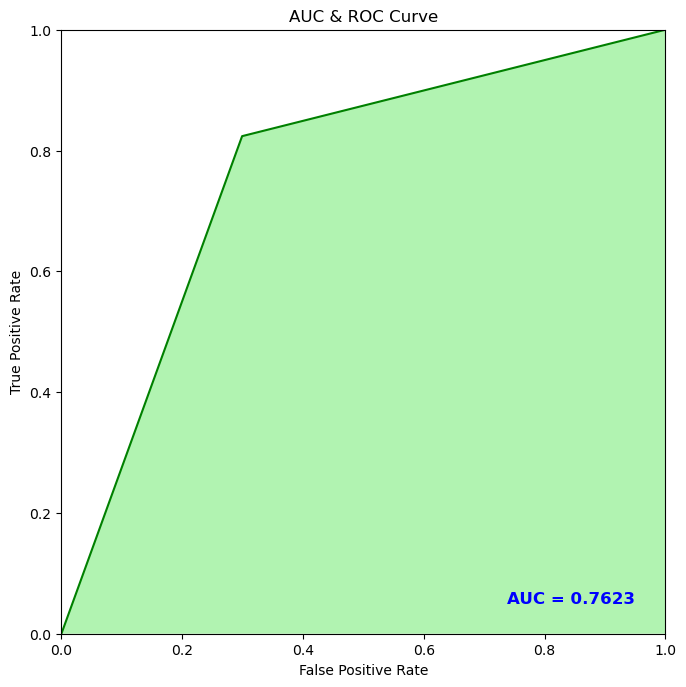

In [22]:
########################### BASE #####################################################
classifier = svm.SVC(class_weight='balanced') # kernel='linear', C=100, gamma=0.001)
classifier.fit(X_train_std, y_train)
y_pred = classifier.predict(X_test_std)
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

bas = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy Score: ", bas)

s = classifier.score(X_test_std, y_test)
print("Score: ", s)

print("Classification report:\n", classification_report(y_test, y_pred))

auc = metrics.roc_auc_score(y_test, y_pred)

false_positive_rate, true_positive_rate, thresolds = metrics.roc_curve(y_test, y_pred)

plt.figure(figsize=(10, 8), dpi=100)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")
plt.plot(false_positive_rate, true_positive_rate, 'g')
plt.fill_between(false_positive_rate, true_positive_rate, facecolor='lightgreen', alpha=0.7)
plt.text(0.95, 0.05, 'AUC = %0.4f' % auc, ha='right', fontsize=12, weight='bold', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [23]:
classifier.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': 'balanced',
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

## Logistic Regression

In [24]:
X_train.shape

(58580, 115)

In [25]:
X_test.head()

,annoCorso,annoDiNascita,codCorso,creditiTotali,flagIdentificato,iscritto,primaIscr,sesso,tipoCorso,tipoStudente,...,facolta_MEDICINA E PSICOLOGIA,facolta_PSICOLOGIA 1,"facolta_SCIENZE MATEMATICHE, FISICHE E NATURALI","facolta_SCIENZE POLITICHE, SOCIOLOGIA, COMUNICAZIONE",facolta_SCIENZE STATISTICHE,facolta_SCUOLA DI INGEGNERIA AEROSPAZIALE,tipoIscrizione_FUORI CORSO,tipoIscrizione_IMMATRICOLAZIONE,tipoIscrizione_IN CORSO,tipoIscrizione_RIPETENTE
0,4,694220400,28230,120,1,False,1420066800,True,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,788914800,30061,120,0,True,1577833200,False,28,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,946681200,30789,360,1,True,1546297200,False,29,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,883609200,31279,120,1,True,1609455600,False,28,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,883609200,30425,180,1,False,1546297200,False,27,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Confusion matrix:
 [[5255 5708]
 [1201 2482]]
Balanced Accuracy Score:  0.5766233688717082
Score:  0.5282671036460467
Classification report:
               precision    recall  f1-score   support

       False       0.81      0.48      0.60     10963
        True       0.30      0.67      0.42      3683

    accuracy                           0.53     14646
   macro avg       0.56      0.58      0.51     14646
weighted avg       0.69      0.53      0.56     14646



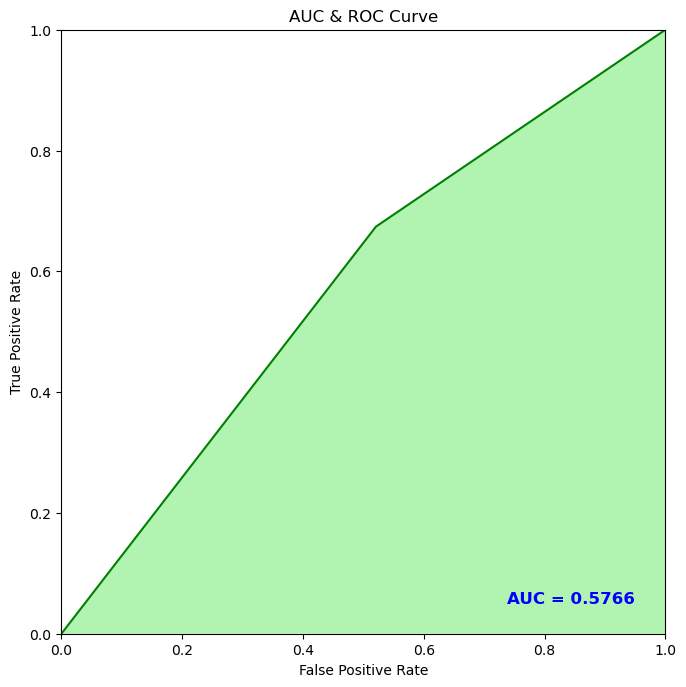

In [26]:
classifier = LogisticRegression(class_weight='balanced')#{0: 0.5, 1:1.5})
classifier.fit(X_smote, y_smote)
y_pred = classifier.predict(X_test) # Mettere L2 -> già c'è di default

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

bas = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy Score: ", bas)

s = classifier.score(X_test, y_test)
print("Score: ", s)

print("Classification report:\n", classification_report(y_test, y_pred))

auc = metrics.roc_auc_score(y_test, y_pred)

false_positive_rate, true_positive_rate, thresolds = metrics.roc_curve(y_test, y_pred)

plt.figure(figsize=(10, 8), dpi=100)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")
plt.plot(false_positive_rate, true_positive_rate, 'g')
plt.fill_between(false_positive_rate, true_positive_rate, facecolor='lightgreen', alpha=0.7)
plt.text(0.95, 0.05, 'AUC = %0.4f' % auc, ha='right', fontsize=12, weight='bold', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [27]:
classifier.get_params()

{'C': 1.0,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

## Gradient Boosting Decision Tree

Confusion matrix:
 [[10333   630]
 [  571  3112]]
Balanced Accuracy Score:  0.893748661512427
Score:  0.9179980882152123
Classification report:
               precision    recall  f1-score   support

       False       0.95      0.94      0.95     10963
        True       0.83      0.84      0.84      3683

    accuracy                           0.92     14646
   macro avg       0.89      0.89      0.89     14646
weighted avg       0.92      0.92      0.92     14646



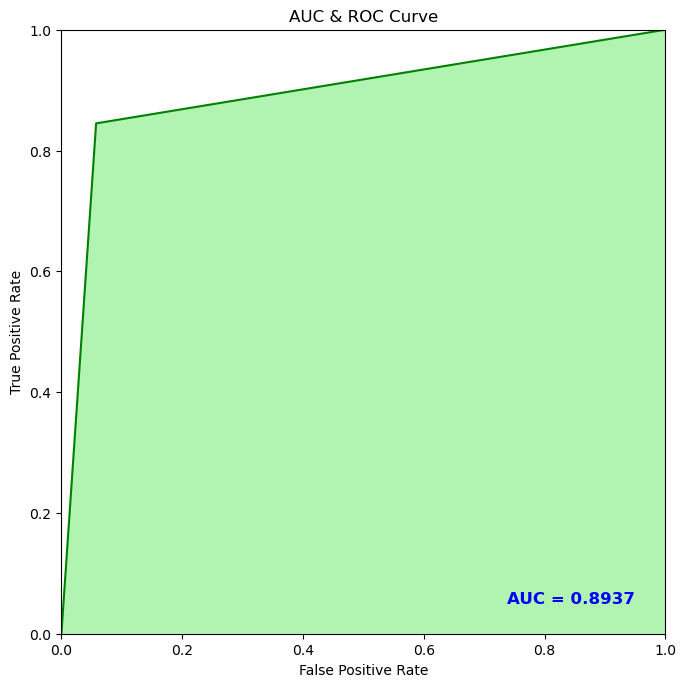

In [28]:
classifier = GradientBoostingClassifier(n_estimators=50, max_depth=9, learning_rate=1)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

bas = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy Score: ", bas)

s = classifier.score(X_test, y_test)
print("Score: ", s)

print("Classification report:\n", classification_report(y_test, y_pred))

auc = metrics.roc_auc_score(y_test, y_pred)

false_positive_rate, true_positive_rate, thresolds = metrics.roc_curve(y_test, y_pred)

plt.figure(figsize=(10, 8), dpi=100)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")
plt.plot(false_positive_rate, true_positive_rate, 'g')
plt.fill_between(false_positive_rate, true_positive_rate, facecolor='lightgreen', alpha=0.7)
plt.text(0.95, 0.05, 'AUC = %0.4f' % auc, ha='right', fontsize=12, weight='bold', color='blue')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [29]:
c_names = X_train.columns
imp = dict(zip(c_names, classifier.feature_importances_))
print(sorted(imp.items()))

[('annoCorso', 0.013750200524099076), ('annoDiNascita', 0.02007859451726746), ('cfuPrenotati', 0.00588358328988853), ('cfuTake', 0.03129058248410483), ('cittadinanza_Extra-UE', 0.0008309170798124576), ('cittadinanza_ITA', 0.0012531994232625606), ('cittadinanza_UE', 0.0005364527447876583), ('codCorso', 0.16029184451213085), ('creditiTotali', 0.005994503082368538), ('facolta_ Dipartimento di Architettura e Progetto', 2.6954941914012146e-05), ('facolta_ Dipartimento di Biologia Ambientale', 6.501974998628204e-09), ("facolta_ Dipartimento di Biologia e Biotecnologie 'Charles Darwin'", 6.167352277608973e-07), ('facolta_ Dipartimento di Chimica', 1.4705223669798819e-05), ('facolta_ Dipartimento di Chimica e tecnologie del farmaco', 3.449048117036418e-05), ('facolta_ Dipartimento di Comunicazione e ricerca sociale', 9.53381543989746e-06), ("facolta_ Dipartimento di Diritto dell'economia", 0.0), ('facolta_ Dipartimento di Diritto ed Economia delle Attività produttive', 1.5393611930466575e-05),

In [30]:
classifier.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 1,
 'loss': 'deviance',
 'max_depth': 9,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 50,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [31]:
X_train.shape

(58580, 115)

## Neural Network

#### Train

In [36]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Activation

X2_train = tf.convert_to_tensor(X_train_std, dtype=tf.int64) 
y2_train = tf.convert_to_tensor(y_train, dtype=tf.int64)

model = Sequential() # Per aggiunta sequenziale di layer
model.add(Dense(32, input_shape=(X_train_std.shape[1],), activation='relu')) # Parametro dropout
model.add(Dense(24, activation='relu')) # Equivalente h1 200->64
model.add(Dense(24, activation='relu')) # Equivalente h1 200->64
model.add(Dense(1, activation='sigmoid')) # sigmoid perché la classificazione è binaria

model.compile(optimizer='adam', loss='mse', metrics=['AUC'])
history = model.fit(X2_train, y2_train, epochs=100, batch_size=1024)

Epoch 1/100
58/58 [==============================] - 3s 34ms/step - loss: 0.7488 - auc: 0.5000
Epoch 2/100
58/58 [==============================] - 2s 41ms/step - loss: 0.7515 - auc: 0.5000
Epoch 3/100
58/58 [==============================] - 2s 29ms/step - loss: 0.7489 - auc: 0.5000
Epoch 4/100
58/58 [==============================] - 2s 42ms/step - loss: 0.7508 - auc: 0.5000
Epoch 5/100
58/58 [==============================] - 2s 37ms/step - loss: 0.7464 - auc: 0.5000
Epoch 6/100
58/58 [==============================] - 3s 58ms/step - loss: 0.7503 - auc: 0.5000
Epoch 7/100
58/58 [==============================] - 4s 67ms/step - loss: 0.7511 - auc: 0.5000
Epoch 8/100
58/58 [==============================] - 3s 42ms/step - loss: 0.7488 - auc: 0.5000
Epoch 9/100
58/58 [==============================] - 2s 37ms/step - loss: 0.7481 - auc: 0.5000
Epoch 10/100
58/58 [==============================] - 2s 29ms/step - loss: 0.7476 - auc: 0.5000
Epoch 11/100
58/58 [=============================

In [37]:
X2_test = tf.convert_to_tensor(X_test_std, dtype=tf.int64)
y2_test = tf.convert_to_tensor(y_test, dtype=tf.int64)
y_pred = model.predict(X2_test)
#Converting predictions to label
pred = list()
for i in range(len(y_pred)):
    pred.append(np.argmax(y_pred[i]))
#Converting one hot encoded test label to label
test = list()
# y2_test = y_test.reset_index()

In [38]:
auc = metrics.roc_auc_score(y_test, y_pred)
auc

0.5

In [39]:
history = model.fit(X2_train, y2_train, validation_data = (X2_test,y2_test), epochs=100, batch_size=1024)

Epoch 1/100
58/58 [==============================] - 3s 48ms/step - loss: 0.7485 - auc: 0.5000 - val_loss: 0.7485 - val_auc: 0.5000
Epoch 2/100
58/58 [==============================] - 2s 42ms/step - loss: 0.7485 - auc: 0.5000 - val_loss: 0.7485 - val_auc: 0.5000
Epoch 3/100
58/58 [==============================] - 2s 32ms/step - loss: 0.7485 - auc: 0.5000 - val_loss: 0.7485 - val_auc: 0.5000
Epoch 4/100
58/58 [==============================] - 2s 26ms/step - loss: 0.7485 - auc: 0.5000 - val_loss: 0.7485 - val_auc: 0.5000
Epoch 5/100
58/58 [==============================] - 2s 34ms/step - loss: 0.7485 - auc: 0.5000 - val_loss: 0.7485 - val_auc: 0.5000
Epoch 6/100
58/58 [==============================] - 1s 24ms/step - loss: 0.7485 - auc: 0.5000 - val_loss: 0.7485 - val_auc: 0.5000
Epoch 7/100
58/58 [==============================] - 2s 29ms/step - loss: 0.7485 - auc: 0.5000 - val_loss: 0.7485 - val_auc: 0.5000
Epoch 8/100
58/58 [==============================] - 2s 31ms/step - loss: 0.

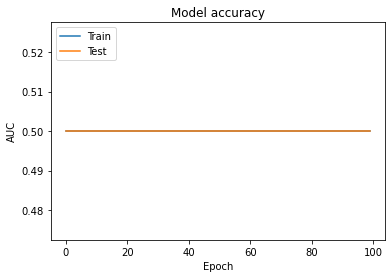

In [40]:
import matplotlib.pyplot as plt
plt.plot(history.history['auc'])
plt.plot(history.history['val_auc'])
plt.title('Model accuracy')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

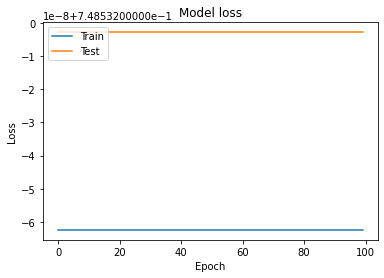

In [41]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss']) 
plt.title('Model loss') 
plt.ylabel('Loss') 
plt.xlabel('Epoch') 
plt.legend(['Train', 'Test'], loc='upper left') 
plt.show()